In [477]:
import matplotlib.pyplot as plt
import numpy as np

In [478]:
# 样本特征
data_X = [
    [1.3, 6],
    [3.5, 5],
    [4.2, 2],
    [5, 3.3],
    [2, 9],
    [5, 7.5],
    [7.2, 4],
    [8.1, 8],
    [9, 2.5]]

In [479]:
# 样本标记
data_y = [0, 0, 0, 0, 1, 1, 1, 1, 1]

In [480]:
# 训练集
X_train = np.array(data_X)
y_train = np.array(data_y)

In [481]:
print(X_train)

[[1.3 6. ]
 [3.5 5. ]
 [4.2 2. ]
 [5.  3.3]
 [2.  9. ]
 [5.  7.5]
 [7.2 4. ]
 [8.1 8. ]
 [9.  2.5]]


In [482]:
print(y_train)

[0 0 0 0 1 1 1 1 1]


In [483]:
print(y_train == 0)  # 判断每个样本的标签是否为 0，返回布尔数组

[ True  True  True  True False False False False False]


In [484]:
print(X_train[y_train == 0])  # 提取所有标签为 0 的样本

[[1.3 6. ]
 [3.5 5. ]
 [4.2 2. ]
 [5.  3.3]]


In [485]:
print(X_train[y_train == 0, 0])  # 提取标签为 0 的样本的第一个特征

[1.3 3.5 4.2 5. ]


In [486]:
print(X_train[y_train == 0, 1])  # 提取标签为 0 的样本的第二个特征

[6.  5.  2.  3.3]


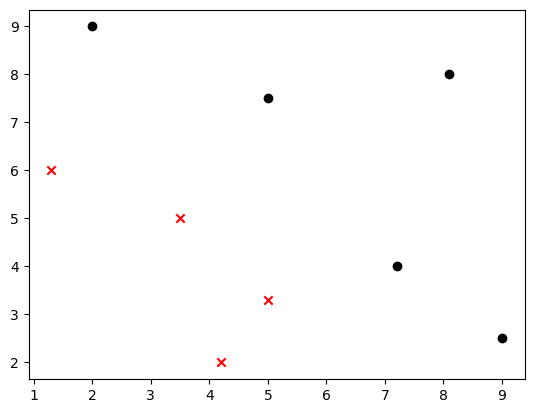

In [487]:
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], color='red', marker='x')  # 绘制类别 0 的样本，使用红色叉号表示
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], color='black', marker='o')  # 绘制类别 1 的样本，使用黑色圆点表示
plt.show()

In [488]:
# 新的样本点
data_new = np.array([4, 5])

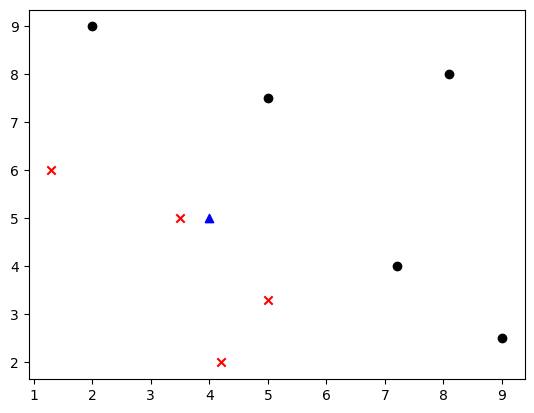

In [489]:
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], color='red', marker='x')
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], color='black', marker='o')
plt.scatter(data_new[0], data_new[1], color="blue", marker="^")  # 绘制新的样本点，使用蓝色三角形表示
plt.show()

## 1.计算新样本点与已知样本点的距离

In [490]:
for data in X_train:
    print(np.sqrt(np.sum((data - data_new) ** 2)))

2.879236009777594
0.5
3.006659275674582
1.9723082923316022
4.47213595499958
2.692582403567252
3.3526109228480423
5.080354318352215
5.5901699437494745


In [491]:
distances = [np.sqrt(np.sum((data - data_new) ** 2)) for data in X_train]
distances

[np.float64(2.879236009777594),
 np.float64(0.5),
 np.float64(3.006659275674582),
 np.float64(1.9723082923316022),
 np.float64(4.47213595499958),
 np.float64(2.692582403567252),
 np.float64(3.3526109228480423),
 np.float64(5.080354318352215),
 np.float64(5.5901699437494745)]

## 2.按距离排序

In [492]:
sort_index = np.argsort(distances)  # 按距离从小到大返回对应元素的索引
sort_index

array([1, 3, 5, 0, 2, 6, 4, 7, 8])

## 3.确定K值

In [493]:
k = 5

## 4.距离最近的k个点投票

In [494]:
first_k = [y_train[i] for i in sort_index[:k]]  # 获取距离最近的K个样本的类别标签
first_k

[np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0)]

## 5.KNN多数投票确定预测类别

In [495]:
from collections import Counter  # 导入计数工具
votes = Counter(first_k)  # 统计最近 5 个样本中各类别出现的次数
result = votes.most_common(1)[0][0]  # 获取出现次数最多的类别
result  # 查看新样本点的预测类别

np.int64(0)

## 6.scikit-learn中的KNN算法

In [496]:
from sklearn.neighbors import KNeighborsClassifier  # 导入 KNN 分类器
knn_classifier = KNeighborsClassifier(n_neighbors=5)  # 创建 KNN 模型，设置 K=5
knn_classifier.fit(X_train, y_train);  # 使用训练集训练模型

In [497]:
data_new.reshape(1, -1)  # 将新样本转换为一行多列的二维数组

array([[4, 5]])

In [498]:
result = knn_classifier.predict(data_new.reshape(1, -1))  # 预测新样本的类别
result

array([0])